<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/rnn/001-simple-rnn-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN - Simple RNN from Scratch

In this notebook, we build a simple Recurrent Neural Network (RNN) from scratch using PyTorch, **without using high-level modules like `nn.RNN`**.  
We'll walk step by step through how an RNN operates internally by manually defining weight matrices, biases, and performing forward passes through the sequence.

We aim to teach our RNN to predict the next number in a simple linear sequence.  
For example, given a sequence:
```
1, 2, 3, 4, ..., n
```
The model should learn to predict:
```
2, 3, 4, 5, ..., n+1
```


In [171]:
def setup_config():
    seq_length = 10 # @param {type:"integer"}
    input_size = 1 # @param {type:"integer"}
    hidden_size = 16 # @param {type:"integer"}
    output_size = 1 # @param {type:"integer"}
    target_seq_shifts = -1 # @param {type:"integer"}
    batch_size = 1 # @param {type:"integer"}
    activation = 'tanh' # @param ['tanh', 'relu']
    return {
        'seq_length': seq_length,
        'input_size': input_size,
        'hidden_size': hidden_size,
        'output_size': output_size,
        'target_seq_shifts' : target_seq_shifts,
        'batch_size': batch_size,
        'activation': activation
    }

CONFIG = setup_config()

Let's generate a sequence of numbers:

In [172]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def generate_sequence(seq_length = None):
    if seq_length is None: seq_length = CONFIG['seq_length']
    start = 1.0
    _start = torch.tensor([start])
    seq = _start + torch.arange(seq_length).float()
    return seq.unsqueeze(-1)

seq = generate_sequence()
seq.shape, seq

(torch.Size([10, 1]),
 tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.]]))

And let's generate the corrresponding sequence (the same sequence shifted by one position):

In [173]:
def get_target_seq(seq, shifts=None):
  if shifts is None: shifts = CONFIG['target_seq_shifts']
  return torch.roll(seq, shifts=shifts, dims=0)
target = get_target_seq(seq)
target.shape, target

(torch.Size([10, 1]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [ 1.]]))

Let's defined the model parameters:

In [174]:
def build_model_params(input_size=None, hidden_size=None):
    if input_size is None: input_size = CONFIG['input_size']
    if hidden_size is None: hidden_size = CONFIG['hidden_size']

    Wxh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
    Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
    Why = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)
    bh = nn.Parameter(torch.zeros(1, hidden_size))
    by = nn.Parameter(torch.zeros(1, input_size))

    return [Wxh, Whh, Why, bh, by]

model_params = build_model_params()
[Wxh, Whh, Why, bh, by] = model_params

Let's pluck the first value in the sequence to feed into the RNN:

In [175]:
x_t = seq[0].unsqueeze(0)  # shape: (1, input_size)
x_t.shape, x_t

(torch.Size([1, 1]), tensor([[1.]]))

Let's initialize the hidden state:

In [176]:
batch_size = CONFIG['batch_size']
hidden_size = CONFIG['hidden_size']
h = torch.zeros(batch_size, hidden_size)
h.shape, h

(torch.Size([1, 16]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

And now let's simulate the forward pass of a single input (one item from the sequence). Basically we want to matmul the input with the input weight matrix, then sum the hidden state matmuled with the hidden state weight matrix, then add a hidden state bias, then run a nonlinear activation over the whole thing):

In [177]:
activation = CONFIG['activation']
if activation == 'tanh': activation_fn = torch.tanh
elif activation == 'relu': activation_fn = torch.relu
else: raise ValueError(f'Unknown activation: {activation}')

h = activation_fn(x_t @ Wxh + h @ Whh + bh)
h.shape, h

(torch.Size([1, 16]),
 tensor([[-1.4883e-01,  2.0463e-02, -1.4973e-01,  4.9572e-02,  4.3185e-02,
          -9.1249e-02, -9.9086e-02,  2.0760e-02,  1.0419e-04,  8.5882e-02,
          -1.5219e-01,  1.0234e-01,  2.2323e-02,  2.4857e-02, -1.7162e-01,
          -2.5470e-02]], grad_fn=<TanhBackward0>))

Now that we have the new hidden state, we can calculate the output by matmuling it with the weight matrix for the output and summing the output bias.

In [178]:
y_t = h @ Why + by
y_t.shape, y_t

(torch.Size([1, 1]), tensor([[-0.0015]], grad_fn=<AddBackward0>))

Processing the whole sequence is similar, with the nuance that the hidden state calculated from the previous input is going to be part of the calculation for the next input in the sequence, this allows information from the previous input to feed into the next allowing preceding context to inform how the next input will be processed:

In [179]:
seq_length = CONFIG['seq_length']
outputs = []
for t in range(seq_length):
    x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
    h = activation_fn(x_t @ Wxh + h @ Whh + bh)
    y_t = h @ Why + by
    outputs.append(y_t)
outputs

[tensor([[0.0019]], grad_fn=<AddBackward0>),
 tensor([[-0.0014]], grad_fn=<AddBackward0>),
 tensor([[0.0003]], grad_fn=<AddBackward0>),
 tensor([[0.0012]], grad_fn=<AddBackward0>),
 tensor([[0.0020]], grad_fn=<AddBackward0>),
 tensor([[0.0032]], grad_fn=<AddBackward0>),
 tensor([[0.0047]], grad_fn=<AddBackward0>),
 tensor([[0.0064]], grad_fn=<AddBackward0>),
 tensor([[0.0081]], grad_fn=<AddBackward0>),
 tensor([[0.0099]], grad_fn=<AddBackward0>)]

We have collected all our outputs, but we need to have them in a shape matching the sequence target, which is a tensor `(20, 1)`, to do so, we need only to concaneate the list:

In [180]:
outputs = torch.cat(outputs, dim=0)
outputs.shape, outputs

(torch.Size([10, 1]),
 tensor([[ 0.0019],
         [-0.0014],
         [ 0.0003],
         [ 0.0012],
         [ 0.0020],
         [ 0.0032],
         [ 0.0047],
         [ 0.0064],
         [ 0.0081],
         [ 0.0099]], grad_fn=<CatBackward0>))

We can now compare the predicted sequence to the target sequence and calculate the loss:

In [181]:
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, target)
loss

tensor(38.4546, grad_fn=<MseLossBackward0>)

We now have everything we need to run a training loop:

In [182]:
# Hyperparameters
num_epochs = 100
learning_rate = 0.01

loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model_params, lr=learning_rate)

loss_history = []
for epoch in range(num_epochs):
    seq = generate_sequence()
    target = get_target_seq(seq)

    # Initialize hidden state
    h = torch.zeros(batch_size, hidden_size)

    outputs = []
    hidden_states = []  # For visualization

    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by

        outputs.append(y_t)
        hidden_states.append(h.detach().numpy())  # store for later

    outputs = torch.cat(outputs, dim=0)

    loss = loss_fn(outputs, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 22.8982
Epoch [20/100], Loss: 11.8609
Epoch [30/100], Loss: 7.4006
Epoch [40/100], Loss: 6.6681
Epoch [50/100], Loss: 6.7003
Epoch [60/100], Loss: 6.3957
Epoch [70/100], Loss: 5.9290
Epoch [80/100], Loss: 5.6653
Epoch [90/100], Loss: 5.4132
Epoch [100/100], Loss: 5.2357


Now that the network is trained, let's check its predictions again:

In [183]:
outputs=[]
with torch.no_grad():
    seq = generate_sequence()
    target = get_target_seq(seq)
    outputs = []
    h = torch.zeros(batch_size, hidden_size)
    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        outputs.append(y_t)
torch.round(torch.cat(outputs)), target

(tensor([[1.],
         [2.],
         [4.],
         [5.],
         [6.],
         [7.],
         [7.],
         [7.],
         [7.],
         [7.]]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [ 1.]]))

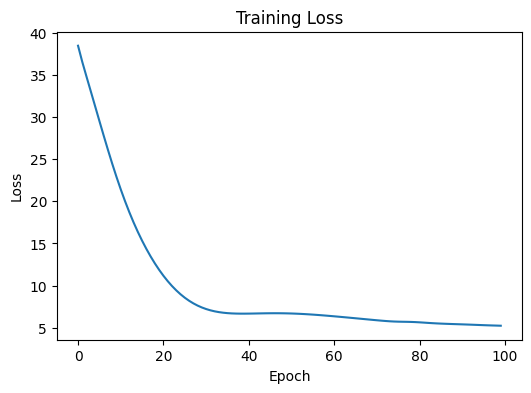

In [184]:
# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

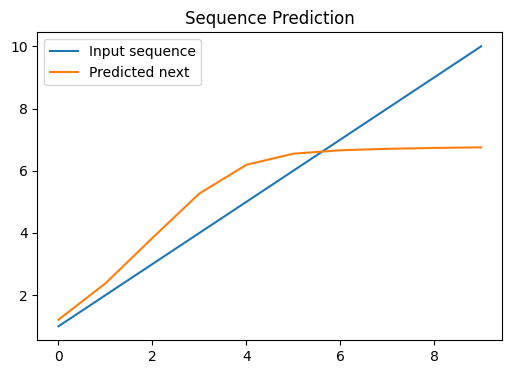

In [185]:
# Test the model (after training)
with torch.no_grad():
    test_seq = generate_sequence()
    h = torch.zeros(batch_size, hidden_size)
    predictions = []
    hidden_states_test = []
    for t in range(seq_length):
        x_t = test_seq[t].unsqueeze(0)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        predictions.append(y_t.item())
        hidden_states_test.append(h.numpy())

    # Plot predictions vs. actual
    plt.figure(figsize=(6, 4))
    plt.plot(test_seq.squeeze().numpy(), label='Input sequence')
    plt.plot(predictions, label='Predicted next')
    plt.legend()
    plt.title('Sequence Prediction')
    plt.show()

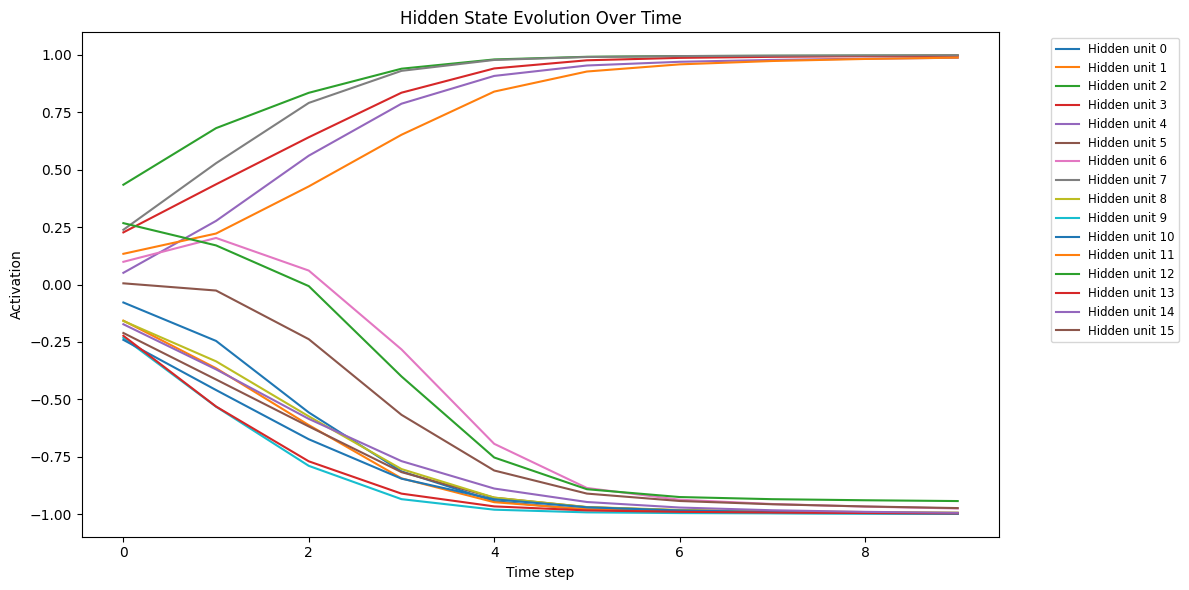

In [186]:
# Visualize hidden state evolution
hidden_states_test = torch.tensor(hidden_states_test).squeeze(1).numpy()  # shape: (seq_length, hidden_size)

plt.figure(figsize=(12, 6))
for i in range(hidden_size):
    plt.plot(hidden_states_test[:, i], label=f'Hidden unit {i}')
plt.title('Hidden State Evolution Over Time')
plt.xlabel('Time step')
plt.ylabel('Activation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

From the graph above we can notice that the hidden activations are converging to the extremes of the tanh. Given the flat surface at these extremes, the gradients will tend to zero, meaning there is no learning, this is the vanishing gradient problem.